# ICC 2027 - Electrical Simulation (IEEE 13 Node Feeder + DG Scenarios)

This notebook rebuilds the electrical simulation pipeline in a cleaner,
more rigorous form, fixing the three issues found in the first version:

1. Fragile relative paths depending on `os.chdir` (broke when the project
   was moved / re-cloned).
2. Driving-point impedance computed with zero-sequence `Zsc0` instead of
   positive-sequence `Zsc1`.
3. A leftover debug print of near-zero losses from before PV systems were
   added, left in the middle of the notebook.

It also adds an explicit phase-check before attaching any PV system, so
bug #3 from the original run (trying to attach 3-phase PV to a 2-phase
bus) cannot happen silently again.


## 0. Configuration

Set `PROJECT_DIR` once, here, to the absolute path of your cloned repo.
Everything else in the notebook uses this instead of relying on the
working directory OpenDSS resets on every `Compile` call.


In [1]:
import os
from pathlib import Path

# EDIT THIS to match where you cloned the repo
PROJECT_DIR = Path(r"C:/Users/mathe/Documents/icc2027-plc-smartgrid")

# electricdss-tst must be cloned INSIDE the project dir (see chat instructions):
# git clone https://github.com/dss-extensions/electricdss-tst.git
FEEDER_FILE = PROJECT_DIR / "electricdss-tst" / "Version8" / "Distrib" / "IEEETestCases" / "13Bus" / "IEEE13Nodeckt.dss"

DATA_DIR = PROJECT_DIR / "data" / "electrical"
FIG_DIR = PROJECT_DIR / "figures" / "electrical"
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

assert FEEDER_FILE.exists(), (
    f"Feeder file not found at {FEEDER_FILE}. "
    "Check that electricdss-tst was cloned inside PROJECT_DIR, "
    "and that PROJECT_DIR points at the right folder."
)
print("Feeder file found:", FEEDER_FILE)

Feeder file found: C:\Users\mathe\Documents\icc2027-plc-smartgrid\electricdss-tst\Version8\Distrib\IEEETestCases\13Bus\IEEE13Nodeckt.dss


## 1. Load OpenDSS and compile the circuit

Key fix: we pass an **absolute path** to `Compile`, built from `PROJECT_DIR`,
instead of a relative string. OpenDSS still changes its own working
directory internally, but since we never rely on relative paths again
after this cell, that no longer matters.


In [2]:
import opendssdirect as dss

dss.Text.Command("Clear")
dss.Text.Command(f"Compile [{FEEDER_FILE.as_posix()}]")
dss.Solution.Solve()

print("Circuit loaded:", dss.Circuit.Name())
print("Number of buses:", len(dss.Circuit.AllBusNames()))
print("Converged:", dss.Solution.Converged())

Circuit loaded: ieee13nodeckt
Number of buses: 16
Converged: True


## 2. Electrical distance to substation (graph-based)

`dss.Bus.Distance()` returns 0 for every bus in this test case because it
requires an `EnergyMeter` element, which the standard IEEE13 file does not
define. Instead we build a graph of the feeder (buses as nodes, lines as
edges weighted by length) and compute shortest-path distance from the
substation bus (`rg60`) using Dijkstra's algorithm.

Note for the paper (Simulation Setup section): this is worth one sentence
explaining why a custom graph-based distance was used instead of the
native OpenDSS function.


In [3]:
import networkx as nx
import pandas as pd

FT_TO_KM = 0.0003048
SUBSTATION_BUS = "rg60"

def build_feeder_graph():
    G = nx.Graph()
    for line in dss.Lines.AllNames():
        dss.Lines.Name(line)
        bus1 = dss.Lines.Bus1().split(".")[0]
        bus2 = dss.Lines.Bus2().split(".")[0]
        length_km = dss.Lines.Length() * FT_TO_KM
        G.add_edge(bus1, bus2, weight=length_km)
    return G

feeder_graph = build_feeder_graph()
distances = nx.single_source_dijkstra_path_length(
    feeder_graph, SUBSTATION_BUS, weight="weight"
)
distance_df = pd.DataFrame(list(distances.items()), columns=["bus", "distance_km"])
distance_df = distance_df.sort_values("distance_km").reset_index(drop=True)
print(distance_df)

     bus  distance_km
0   rg60     0.000000
1    632     0.609600
2    633     0.762000
3    645     0.762000
4    670     0.812902
5    646     0.853440
6    671     1.219200
7    692     1.219200
8    684     1.310640
9    675     1.371600
10   611     1.402080
11   680     1.524000
12   652     1.554480


## 3. Bus phase count (fixes bug #3)

Before picking PV buses, we check how many phases each bus actually has.
This is the check that was missing when a 3-phase PV system was first
attached to bus 645 (2-phase only), which caused a convergence failure.
Any future change to `PV_BUSES` is now automatically validated.


In [4]:
def get_bus_phase_counts():
    phase_counts = {}
    for bus in dss.Circuit.AllBusNames():
        dss.Circuit.SetActiveBus(bus)
        phase_counts[bus] = dss.Bus.NumNodes()
    return phase_counts

phase_counts = get_bus_phase_counts()
phase_df = pd.DataFrame(
    sorted(phase_counts.items()), columns=["bus", "num_nodes"]
)
print(phase_df)

PV_BUSES = ["671", "675", "692", "633"]

for bus in PV_BUSES:
    n = phase_counts.get(bus)
    assert n is not None and n >= 3, (
        f"Bus {bus} has {n} nodes, cannot attach a 3-phase PV system. "
        "Pick a different bus or adjust the PVSystem phase count."
    )
print("All PV buses validated as 3-phase compatible:", PV_BUSES)

          bus  num_nodes
0         611          1
1         632          3
2         633          3
3         634          3
4         645          2
5         646          2
6         650          3
7         652          1
8         670          3
9         671          3
10        675          3
11        680          3
12        684          2
13        692          3
14       rg60          3
15  sourcebus          3
All PV buses validated as 3-phase compatible: ['671', '675', '692', '633']


## 4. Total feeder load


In [5]:
def get_total_load_kw():
    total = 0.0
    for load in dss.Loads.AllNames():
        dss.Loads.Name(load)
        total += dss.Loads.kW()
    return total

TOTAL_LOAD_KW = get_total_load_kw()
print("Total feeder load (kW):", TOTAL_LOAD_KW)

Total feeder load (kW): 3466.0


## 5. Driving-point impedance (fixed: positive-sequence, `Zsc1`)

The original version used `Zsc0()` (zero-sequence short-circuit
impedance), which is more relevant to ground-fault studies. For a PLC
channel model, positive-sequence impedance (`Zsc1`) is the standard
choice in the literature, so that is what this version uses.


In [6]:
def get_driving_point_impedance():
    
    #Computes positive-sequence driving-point impedance magnitude (ohms)
    #at each bus, using OpenDSS's Zsc1 (positive-sequence short-circuit
    #impedance). This replaces the original Zsc0 (zero-sequence) version.
    
    results = []
    for bus in dss.Circuit.AllBusNames():
        dss.Circuit.SetActiveBus(bus)
        try:
            dss.Bus.ZscRefresh()
            zsc1 = dss.Bus.Zsc1()  # (R1, X1) positive-sequence
            z_mag = (zsc1[0] ** 2 + zsc1[1] ** 2) ** 0.5 if len(zsc1) >= 2 else None
        except Exception:
            z_mag = None
        results.append({"bus": bus, "z_ohm_positive_seq": z_mag})
    return pd.DataFrame(results)

z_df = get_driving_point_impedance()
print(z_df)

          bus  z_ohm_positive_seq
0   sourcebus            0.661167
1         650            0.001143
2        rg60            0.001738
3         633            0.317177
4         634            0.014357
5         671            0.453066
6         645            0.368143
7         646            0.442836
8         692            0.453066
9         675            0.504787
10        611            0.977546
11        652            1.022998
12        670            0.305495
13        632            0.230614
14        680            0.571272
15        684            0.521703


## 6. DG scenario runner

Refactored into one function used both for the static (0/20/40/60%)
scenarios and the hourly simulation below, so the PV-injection logic
only exists in one place.


In [7]:
DG_LEVELS = [0, 20, 40, 60]

def run_dg_scenario(penetration_pct, load_mult=1.0):
    
    #Recompiles the circuit fresh, optionally sets a load multiplier
    #(for the hourly runs), adds PV systems at PV_BUSES sized to reach
    #the requested penetration_pct of total feeder load, solves the
    #power flow, and returns a per-bus voltage/angle dataframe.
    
    dss.Text.Command("Clear")
    dss.Text.Command(f"Compile [{FEEDER_FILE.as_posix()}]")
    dss.Text.Command(f"set LoadMult={load_mult}")

    if penetration_pct > 0:
        total_pv_kw = TOTAL_LOAD_KW * (penetration_pct / 100)
        pv_kw_each = total_pv_kw / len(PV_BUSES)
        for bus in PV_BUSES:
            dss.Text.Command(
                f"New PVSystem.PV_{bus} Bus1={bus} Phases=3 kV=4.16 "
                f"kVA={pv_kw_each} Pmpp={pv_kw_each} irradiance=1"
            )

    dss.Solution.Solve()
    converged = dss.Solution.Converged()

    data = []
    for bus in dss.Circuit.AllBusNames():
        dss.Circuit.SetActiveBus(bus)
        v = dss.Bus.puVmagAngle()
        data.append({
            "bus": bus,
            "voltage_pu": v[0] if len(v) > 0 else None,
            "angle": v[1] if len(v) > 1 else None,
            "penetration_pct": penetration_pct,
            "load_mult": load_mult,
            "converged": converged,
        })
    return pd.DataFrame(data)

## 7. Static scenarios (0/20/40/60% DG, nominal load)

Same four scenarios as before, now merged with distance in one step
and with an explicit convergence check instead of just printing it.


In [8]:
static_scenarios = []
for p in DG_LEVELS:
    df = run_dg_scenario(p)
    if not df["converged"].iloc[0]:
        raise RuntimeError(f"Scenario {p}% DG failed to converge")
    static_scenarios.append(df)
    print(f"Scenario {p}% DG solved. Converged:", df["converged"].iloc[0])

all_scenarios_df = pd.concat(static_scenarios, ignore_index=True)
all_scenarios_df = all_scenarios_df.merge(distance_df, on="bus", how="left")
all_scenarios_df.to_csv(DATA_DIR / "all_dg_scenarios.csv", index=False)
print(all_scenarios_df.head())

Scenario 0% DG solved. Converged: True
Scenario 20% DG solved. Converged: True
Scenario 40% DG solved. Converged: True
Scenario 60% DG solved. Converged: True
         bus  voltage_pu      angle  penetration_pct  load_mult  converged  \
0  sourcebus    0.999974  29.992739                0        1.0       True   
1        650    0.999911  -0.011139                0        1.0       True   
2       rg60    1.056033  -0.013087                0        1.0       True   
3        633    1.011301  -2.594629                0        1.0       True   
4        634    0.987160  -3.279911                0        1.0       True   

   distance_km  
0          NaN  
1          NaN  
2        0.000  
3        0.762  
4          NaN  


## 8. Losses and line currents (base case, no stray debug print)

This replaces the earlier standalone "total losses" test cell. Losses
here are computed only after PV systems are properly added by
`run_dg_scenario`, so there is no near-zero placeholder value to
confuse a reader later.


In [9]:
def get_losses_and_currents():
    total_losses_kw = dss.Circuit.Losses()[0] / 1000  # W to kW
    line_currents = []
    for line in dss.Lines.AllNames():
        dss.Lines.Name(line)
        currents = dss.CktElement.CurrentsMagAng()
        max_current = max(currents[::2]) if currents else None
        line_currents.append({"line": line, "current_A": max_current})
    return total_losses_kw, pd.DataFrame(line_currents)

# Re-run the base case explicitly right before measuring losses/currents,
# so we know exactly which state we are reading from.
_ = run_dg_scenario(0)
losses_kw, currents_df = get_losses_and_currents()
print("Total feeder losses, base case (kW):", losses_kw)
print(currents_df)

Total feeder losses, base case (kW): 112.3917090551033
      line   current_A
0   650632  591.742097
1   632670  481.890407
2   670671  473.769714
3   671680    0.000598
4   632633   81.893780
5   632645  143.309481
6   645646   64.377279
7   692675  206.841793
8   671684   71.152601
9   684611   71.152601
10  684652   62.714715
11  671692  230.933157


## 9. Losses summary across all DG levels


In [10]:
loss_summary = []
for p in DG_LEVELS:
    _ = run_dg_scenario(p)
    loss_summary.append({
        "penetration_pct": p,
        "losses_kw": dss.Circuit.Losses()[0] / 1000,
    })

loss_df = pd.DataFrame(loss_summary)
loss_df.to_csv(DATA_DIR / "losses_summary.csv", index=False)
print(loss_df)

   penetration_pct   losses_kw
0                0  112.391709
1               20   82.222255
2               40   59.224967
3               60   43.108244


## 10. Hourly simulation (24h x 4 DG levels x 13 buses)

Same daily load-multiplier curve as the original run, now built on top
of the shared `run_dg_scenario` function instead of a separate,
duplicated implementation.


In [11]:
LOAD_CURVE = [
    0.6, 0.55, 0.5, 0.5, 0.55, 0.65, 0.8, 0.9, 0.95, 1.0, 1.0, 0.95,
    0.9, 0.9, 0.95, 1.0, 1.05, 1.1, 1.05, 0.95, 0.85, 0.75, 0.7, 0.65,
]
assert len(LOAD_CURVE) == 24

all_hourly = []
for p in DG_LEVELS:
    for hour, mult in enumerate(LOAD_CURVE):
        df = run_dg_scenario(p, load_mult=mult)
        df["hour"] = hour
        df["losses_kw"] = dss.Circuit.Losses()[0] / 1000
        all_hourly.append(df)

hourly_df = pd.concat(all_hourly, ignore_index=True)
hourly_df = hourly_df.merge(distance_df, on="bus", how="left")
hourly_df.to_csv(DATA_DIR / "hourly_dg_scenarios.csv", index=False)
print(hourly_df.shape)
print(hourly_df.head())

(1536, 9)
         bus  voltage_pu      angle  penetration_pct  load_mult  converged  \
0  sourcebus    1.000041  29.995378                0        0.6       True   
1        650    1.000011  -0.007085                0        0.6       True   
2       rg60    1.043697  -0.008654                0        0.6       True   
3        633    1.020842  -1.572894                0        0.6       True   
4        634    1.006656  -1.972323                0        0.6       True   

   hour  losses_kw  distance_km  
0     0  36.480461          NaN  
1     0  36.480461          NaN  
2     0  36.480461        0.000  
3     0  36.480461        0.762  
4     0  36.480461          NaN  


## 11. Save impedance handoff file


In [12]:
z_df.to_csv(DATA_DIR / "bus_impedance.csv", index=False)
print("Saved:", DATA_DIR / "bus_impedance.csv")

Saved: C:\Users\mathe\Documents\icc2027-plc-smartgrid\data\electrical\bus_impedance.csv


## 12. Figures

Same six figures as the original notebook, regenerated from the
corrected data and saved into `FIG_DIR`.


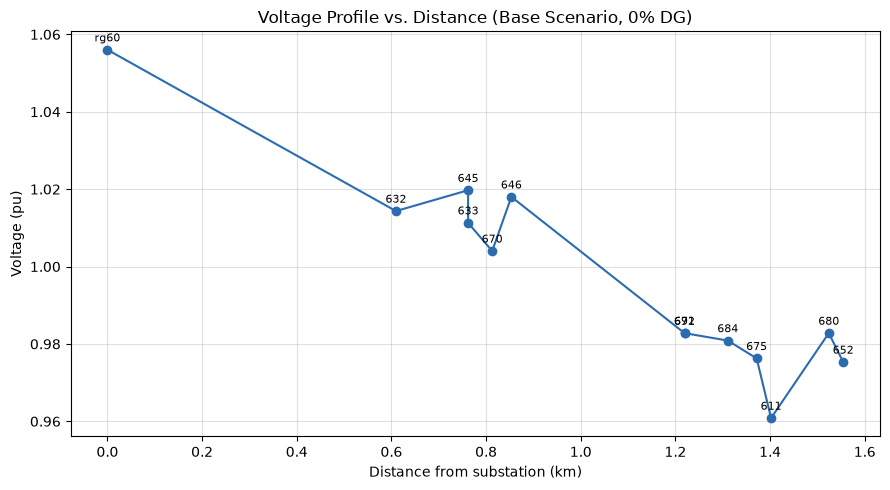

In [13]:
import matplotlib.pyplot as plt

base_scenario = all_scenarios_df[all_scenarios_df["penetration_pct"] == 0].dropna(subset=["distance_km"])
base_scenario = base_scenario.sort_values("distance_km")

plt.figure(figsize=(9, 5))
plt.plot(base_scenario["distance_km"], base_scenario["voltage_pu"], marker="o", color="#2b6cb0")
for _, row in base_scenario.iterrows():
    plt.annotate(row["bus"], (row["distance_km"], row["voltage_pu"]),
                 textcoords="offset points", xytext=(0, 6), fontsize=8, ha="center")
plt.xlabel("Distance from substation (km)")
plt.ylabel("Voltage (pu)")
plt.title("Voltage Profile vs. Distance (Base Scenario, 0% DG)")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / "voltage_profile_base.png", dpi=300)
plt.show()

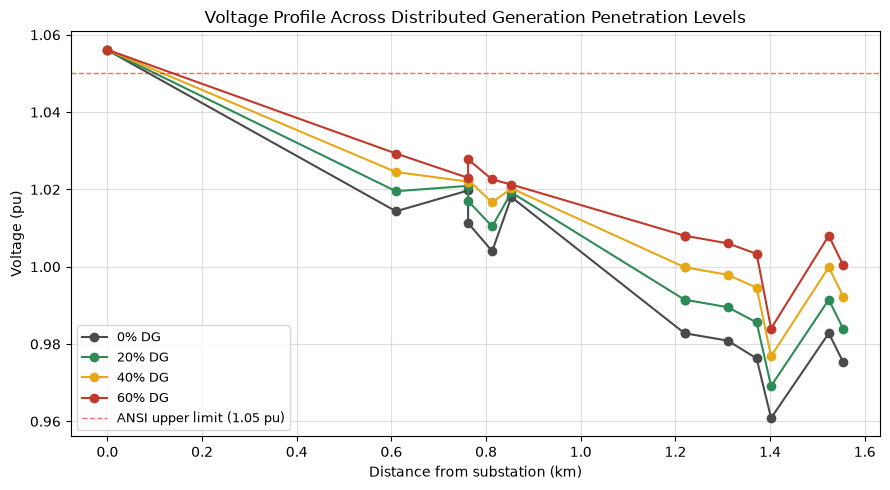

In [14]:
colors = {0: "#4a4a4a", 20: "#2e8b57", 40: "#e6a817", 60: "#c0392b"}

plt.figure(figsize=(9, 5))
for p in DG_LEVELS:
    sub = all_scenarios_df[all_scenarios_df["penetration_pct"] == p].dropna(subset=["distance_km"])
    sub = sub.sort_values("distance_km")
    plt.plot(sub["distance_km"], sub["voltage_pu"], marker="o", label=f"{p}% DG", color=colors[p])
plt.axhline(1.05, color="red", linestyle="--", linewidth=1, alpha=0.6, label="ANSI upper limit (1.05 pu)")
plt.xlabel("Distance from substation (km)")
plt.ylabel("Voltage (pu)")
plt.title("Voltage Profile Across Distributed Generation Penetration Levels")
plt.legend(fontsize=9)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / "voltage_profile_dg_comparison.png", dpi=300)
plt.show()

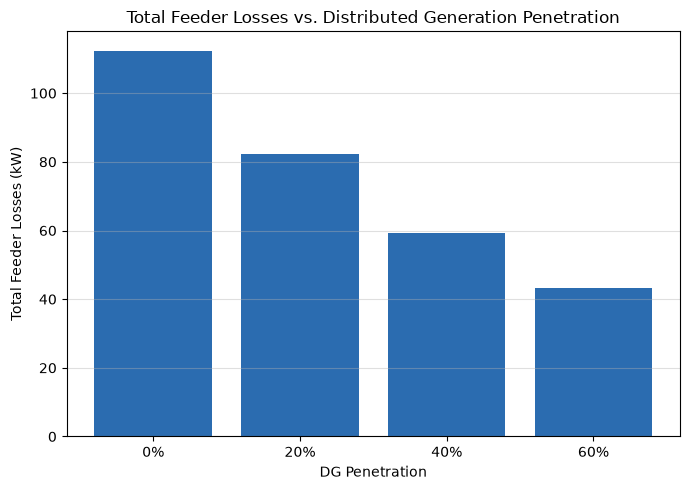

In [15]:
plt.figure(figsize=(7, 5))
plt.bar(loss_df["penetration_pct"].astype(str) + "%", loss_df["losses_kw"], color="#2b6cb0")
plt.xlabel("DG Penetration")
plt.ylabel("Total Feeder Losses (kW)")
plt.title("Total Feeder Losses vs. Distributed Generation Penetration")
plt.grid(True, axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / "losses_vs_dg.png", dpi=300)
plt.show()

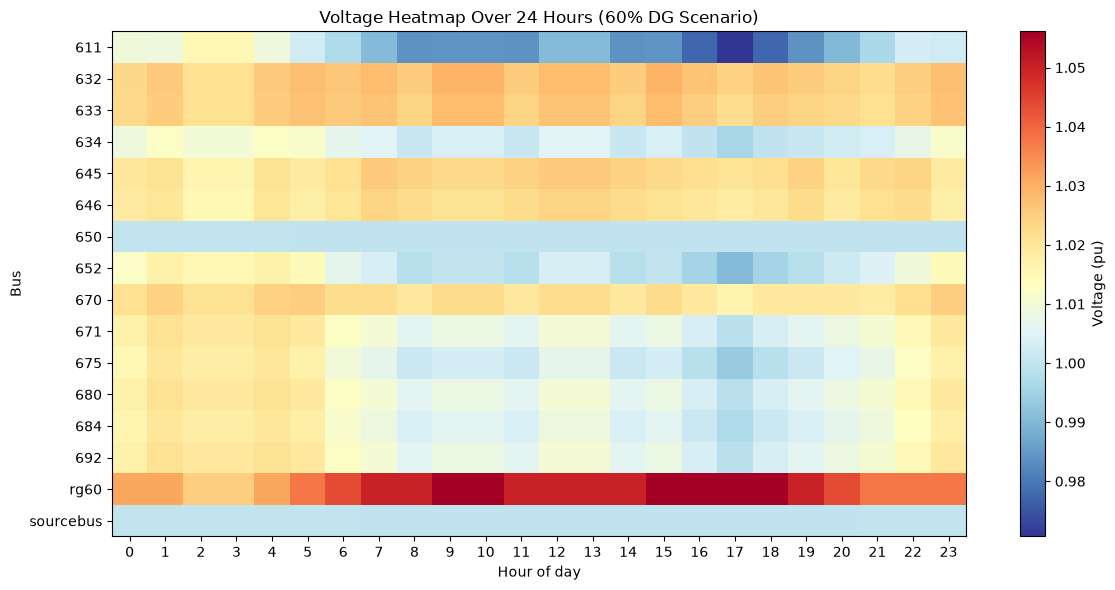

In [16]:
heat_data = hourly_df[hourly_df["penetration_pct"] == 60].pivot(index="bus", columns="hour", values="voltage_pu")

plt.figure(figsize=(12, 6))
plt.imshow(heat_data, aspect="auto", cmap="RdYlBu_r")
plt.colorbar(label="Voltage (pu)")
plt.yticks(range(len(heat_data.index)), heat_data.index)
plt.xticks(range(24), range(24))
plt.xlabel("Hour of day")
plt.ylabel("Bus")
plt.title("Voltage Heatmap Over 24 Hours (60% DG Scenario)")
plt.tight_layout()
plt.savefig(FIG_DIR / "voltage_heatmap_60dg.png", dpi=300)
plt.show()

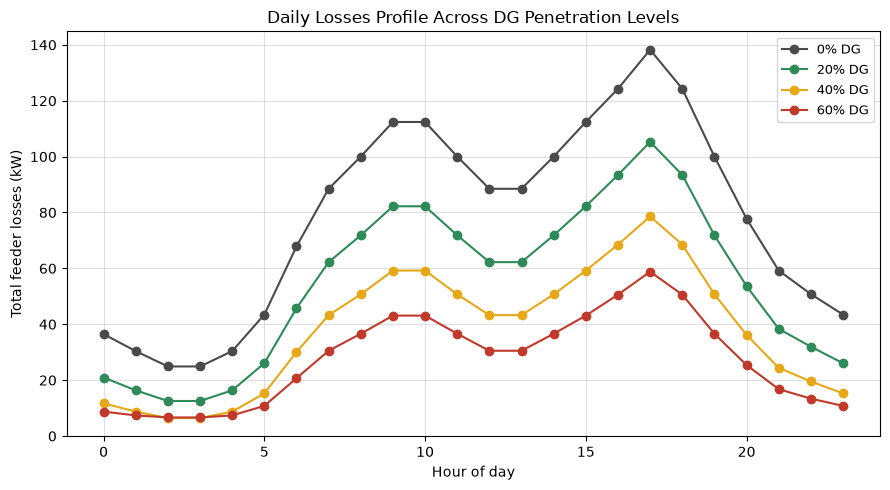

In [17]:
plt.figure(figsize=(9, 5))
for p in DG_LEVELS:
    sub = hourly_df[hourly_df["penetration_pct"] == p].groupby("hour")["losses_kw"].mean()
    plt.plot(sub.index, sub.values, marker="o", label=f"{p}% DG", color=colors[p])
plt.xlabel("Hour of day")
plt.ylabel("Total feeder losses (kW)")
plt.title("Daily Losses Profile Across DG Penetration Levels")
plt.legend(fontsize=9)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / "daily_losses_profile.png", dpi=300)
plt.show()

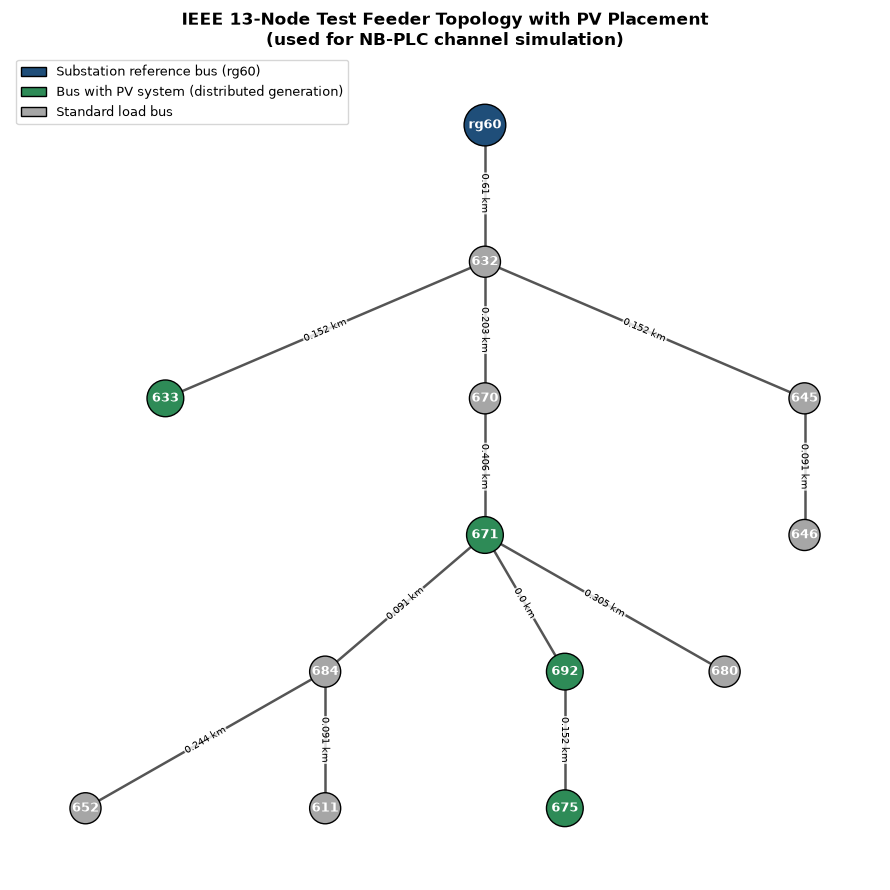

In [18]:
import matplotlib.patches as mpatches

pos = {
    "rg60": (0, 10), "632": (0, 8), "633": (-2, 6), "634": (-2, 4),
    "645": (2, 6), "646": (2, 4), "670": (0, 6), "671": (0, 4),
    "684": (-1, 2), "611": (-1, 0), "652": (-2.5, 0), "680": (1.5, 2),
    "692": (0.5, 2), "675": (0.5, 0),
}

G_plot = nx.Graph()
for line in dss.Lines.AllNames():
    dss.Lines.Name(line)
    b1 = dss.Lines.Bus1().split(".")[0]
    b2 = dss.Lines.Bus2().split(".")[0]
    length_km = dss.Lines.Length() * FT_TO_KM
    G_plot.add_edge(b1, b2, weight=round(length_km, 3))

pv_buses_set = set(PV_BUSES)
node_colors, node_sizes = [], []
for node in G_plot.nodes():
    if node == SUBSTATION_BUS:
        node_colors.append("#1f4e79"); node_sizes.append(900)
    elif node in pv_buses_set:
        node_colors.append("#2e8b57"); node_sizes.append(700)
    else:
        node_colors.append("#a6a6a6"); node_sizes.append(500)

fig, ax = plt.subplots(figsize=(9, 9))
nx.draw_networkx_edges(G_plot, pos, ax=ax, edge_color="#555555", width=1.8)
nx.draw_networkx_nodes(G_plot, pos, ax=ax, node_color=node_colors,
                        node_size=node_sizes, edgecolors="black", linewidths=1.0)
nx.draw_networkx_labels(G_plot, pos, ax=ax, font_size=9, font_weight="bold", font_color="white")
edge_labels = {k: f"{v} km" for k, v in nx.get_edge_attributes(G_plot, "weight").items()}
nx.draw_networkx_edge_labels(G_plot, pos, edge_labels=edge_labels, ax=ax, font_size=7,
                              label_pos=0.5, bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.8))
legend_elements = [
    mpatches.Patch(facecolor="#1f4e79", edgecolor="black", label="Substation reference bus (rg60)"),
    mpatches.Patch(facecolor="#2e8b57", edgecolor="black", label="Bus with PV system (distributed generation)"),
    mpatches.Patch(facecolor="#a6a6a6", edgecolor="black", label="Standard load bus"),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=9, frameon=True)
ax.set_title("IEEE 13-Node Test Feeder Topology with PV Placement\n(used for NB-PLC channel simulation)",
             fontsize=12, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "feeder_topology_pv.png", dpi=300, bbox_inches="tight")
plt.show()

## 13. Handoff summary


In [19]:
print("Electrical simulation complete. Files ready for handoff:")
for f in sorted(DATA_DIR.glob("*.csv")):
    print(" -", f.relative_to(PROJECT_DIR))
for f in sorted(FIG_DIR.glob("*.png")):
    print(" -", f.relative_to(PROJECT_DIR))

Electrical simulation complete. Files ready for handoff:
 - data\electrical\all_dg_scenarios.csv
 - data\electrical\bus_impedance.csv
 - data\electrical\hourly_dg_scenarios.csv
 - data\electrical\losses_summary.csv
 - figures\electrical\daily_losses_profile.png
 - figures\electrical\feeder_topology_pv.png
 - figures\electrical\losses_vs_dg.png
 - figures\electrical\voltage_heatmap_60dg.png
 - figures\electrical\voltage_profile_base.png
 - figures\electrical\voltage_profile_dg_comparison.png
